# 03. Multi-Period DiD with Heterogeneous Dynamic Effects in the Sun-Abraham Style

This notebook extends the previous multi-period DiD lesson to the case where treatment effects vary across cohorts and over event time.

That is the core setting studied by Sun and Abraham:
- treatment timing is staggered,
- dynamic effects evolve after treatment begins,
- those dynamic effects can differ across cohorts, and
- a naive two-way fixed effects event-study regression can mix together the wrong comparisons.

The goal here is instructional: show the problem in a marketing rollout and then estimate the event-study pattern with an interaction-weighted approach.

## Learning Goals

By the end of this notebook, you should be able to:
- Explain the source of the staggered treatment shock.
- State the identification assumptions for a staggered event-study design.
- Check whether treated and never-treated markets look similar before treatment.
- Assess pre-trends visually.
- Understand why a naive TWFE event-study regression can be misleading when effects are heterogeneous.
- Estimate dynamic treatment effects with a Sun-Abraham style interaction-weighted event-study.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import statsmodels.formula.api as smf

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
rng = np.random.default_rng(2028)

## Marketing Setup And Source Of The Shock

We keep the same marketing story as in Notebook 02. A retailer rolls out an AI-driven personalization engine across local markets in waves because vendor onboarding capacity is limited.

The rollout schedule is:
- one wave starts in month 5,
- one starts in month 7,
- one starts in month 9, and
- some markets remain untreated during the sample.

The **shock** is the first month the engine turns on in a market. The schedule is fixed by operational readiness, not by sudden local demand changes.

In this notebook, the treatment effect is allowed to evolve after rollout and to differ across rollout cohorts.

In [14]:
cohort_schedule = {5: 6, 7: 8, 9: 12, 0: 12}
n_months = 12

market_rows = []
for first_treat_month, count in cohort_schedule.items():
    for _ in range(count):
        market_rows.append(
            {
                "market_id": f"M{len(market_rows) + 1:02d}",
                "cohort": first_treat_month,
                "ever_treated": int(first_treat_month > 0),
                "population_index": rng.normal(100, 10),
                "digital_share": np.clip(rng.normal(0.42, 0.05), 0.25, 0.65),
                "historical_roas": rng.normal(4.0, 0.35),
                "market_fe": rng.normal(0, 6),
            }
        )

markets = pd.DataFrame(market_rows)
markets["cohort_label"] = markets["cohort"].map({0: "Never treated", 5: "Cohort 5", 7: "Cohort 7", 9: "Cohort 9"})

months = pd.DataFrame({"month": np.arange(1, n_months + 1)})
months["common_trend"] = np.array([-6, -4, -1, 1, 2, 4, 6, 7, 9, 11, 12, 14])
months["seasonality"] = np.array([-4, -2, -1, 0, 2, 3, 4, 6, 5, 7, 8, 6])

df = markets.assign(key=1).merge(months.assign(key=1), on="key").drop(columns="key")
df["treated"] = ((df["cohort"] > 0) & (df["month"] >= df["cohort"])).astype(int)
df["event_time"] = np.where(df["cohort"] > 0, df["month"] - df["cohort"], np.nan)

heterogeneous_paths = {
    5: {0: 4, 1: 6, 2: 8, 3: 9},
    7: {0: 12, 1: 17, 2: 22, 3: 26},
    9: {0: 24, 1: 31, 2: 38, 3: 44},
}

df["true_effect"] = 0.0
for cohort, path in heterogeneous_paths.items():
    mask = (df["cohort"] == cohort) & (df["treated"] == 1)
    capped_event = np.minimum(df.loc[mask, "event_time"].astype(int), 3)
    df.loc[mask, "true_effect"] = capped_event.map(path).to_numpy()

df["orders"] = (
    180
    + 0.70 * df["population_index"]
    + 45 * df["digital_share"]
    + 8 * df["historical_roas"]
    + df["market_fe"]
    + df["common_trend"]
    + df["seasonality"]
    + df["true_effect"]
    + rng.normal(0, 7, len(df))
).round(2)

df[["market_id", "cohort_label", "month", "treated", "event_time", "orders"]].head()

,market_id,cohort_label,month,treated,event_time,orders
0,M01,Cohort 5,1,0,-4.000,260.180
1,M01,Cohort 5,2,0,-3.000,290.580
2,M01,Cohort 5,3,0,-2.000,286.490
3,M01,Cohort 5,4,0,-1.000,287.910
4,M01,Cohort 5,5,1,0.000,292.560


## Identification Assumptions

The core assumptions are:
- **Parallel trends for untreated outcomes:** absent treatment, each treated cohort would have evolved like the never-treated markets.
- **No anticipation:** markets do not respond before their rollout month.
- **No spillovers:** rollout in one market does not affect never-treated markets.
- **Stable composition and measurement:** the set of markets and the outcome definition do not change.
- **Absorbing treatment:** once a market adopts, it stays treated.

The extra issue in Sun-Abraham is not identification alone. It is that with heterogeneous dynamic effects, a standard TWFE event-study regression does not cleanly recover the event-time effects we care about.

## 1. Are Treated And Never-Treated Markets Similar Before Rollout?

Start with the same basic diagnostic as in Notebook 02: compare market characteristics and pre-rollout outcomes before anyone is treated.

In [15]:
first_treated_month = min(month for month in cohort_schedule if month > 0)
pre_rollout_market = (
    df[df["month"] < first_treated_month]
    .groupby("market_id", as_index=False)
    .agg(pre_rollout_orders=("orders", "mean"))
)

market_level = markets.merge(pre_rollout_market, on="market_id")

covariate_labels = {
    "population_index": "Population index",
    "digital_share": "Digital share",
    "historical_roas": "Historical ROAS",
    "pre_rollout_orders": "Average pre-rollout orders",
}

balance_rows = []
for covariate, label in covariate_labels.items():
    treated_values = market_level.loc[market_level["ever_treated"] == 1, covariate]
    control_values = market_level.loc[market_level["ever_treated"] == 0, covariate]
    pooled_sd = np.sqrt((treated_values.var(ddof=1) + control_values.var(ddof=1)) / 2)
    balance_model = smf.ols(f"{covariate} ~ ever_treated", data=market_level).fit(cov_type="HC1")
    balance_rows.append(
        {
            "variable": label,
            "treated_mean": treated_values.mean(),
            "never_treated_mean": control_values.mean(),
            "difference": treated_values.mean() - control_values.mean(),
            "std_diff": (treated_values.mean() - control_values.mean()) / pooled_sd,
            "p_value": balance_model.pvalues["ever_treated"],
        }
    )

balance_table = pd.DataFrame(balance_rows)
balance_table.round(3)

,variable,treated_mean,never_treated_mean,difference,std_diff,p_value
0,Population index,101.190,99.185,2.005,0.279,0.390
1,Digital share,0.413,0.420,-0.007,-0.123,0.730
2,Historical ROAS,3.982,3.848,0.134,0.425,0.171
3,Average pre-rollout orders,298.051,294.795,3.256,0.360,0.278


In [16]:
market_level.groupby("cohort_label")[["population_index", "digital_share", "historical_roas", "pre_rollout_orders"]].mean().round(3)

,population_index,digital_share,historical_roas,pre_rollout_orders
cohort_label,,,,
Cohort 5,100.623,0.402,3.840,295.032
Cohort 7,101.574,0.419,4.019,302.851
Cohort 9,101.218,0.415,4.028,296.359
Never treated,99.185,0.420,3.848,294.795


## 2. Illustrate The Trajectory And Check Pre-Trends

Plot average outcomes by cohort over calendar time. We want to see similar pre-treatment trajectories and then cohort-specific divergence after rollout.

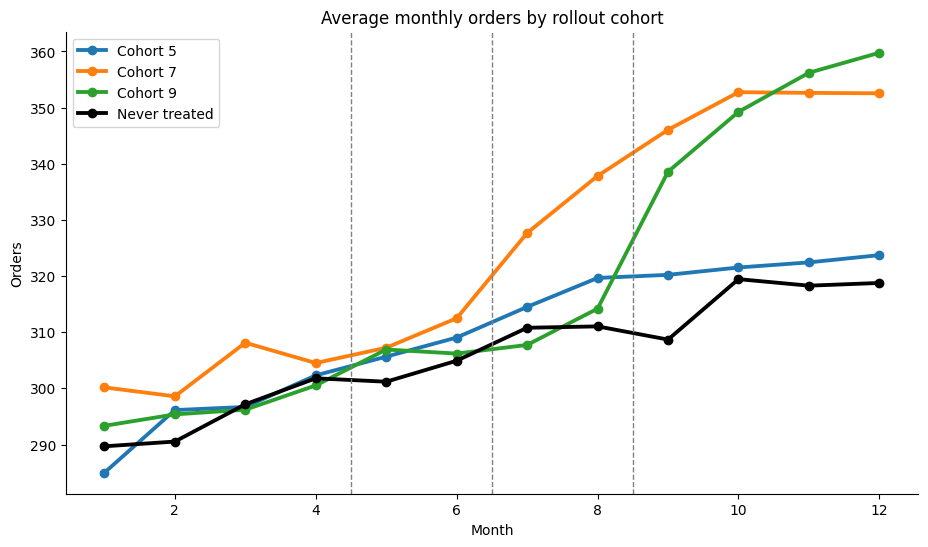

In [17]:
calendar_means = df.groupby(["month", "cohort_label"], as_index=False)["orders"].mean()
color_map = {
    "Never treated": "black",
    "Cohort 5": "tab:blue",
    "Cohort 7": "tab:orange",
    "Cohort 9": "tab:green",
}

fig, ax = plt.subplots(figsize=(11, 6))
for cohort_label, cohort_df in calendar_means.groupby("cohort_label"):
    ax.plot(
        cohort_df["month"],
        cohort_df["orders"],
        color=color_map[cohort_label],
        marker="o",
        linewidth=2.75,
        label=cohort_label,
    )

for adoption_month in [5, 7, 9]:
    ax.axvline(adoption_month - 0.5, color="gray", linestyle="--", linewidth=1)

ax.set_title("Average monthly orders by rollout cohort")
ax.set_xlabel("Month")
ax.set_ylabel("Orders")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.legend(frameon=True)
plt.show()

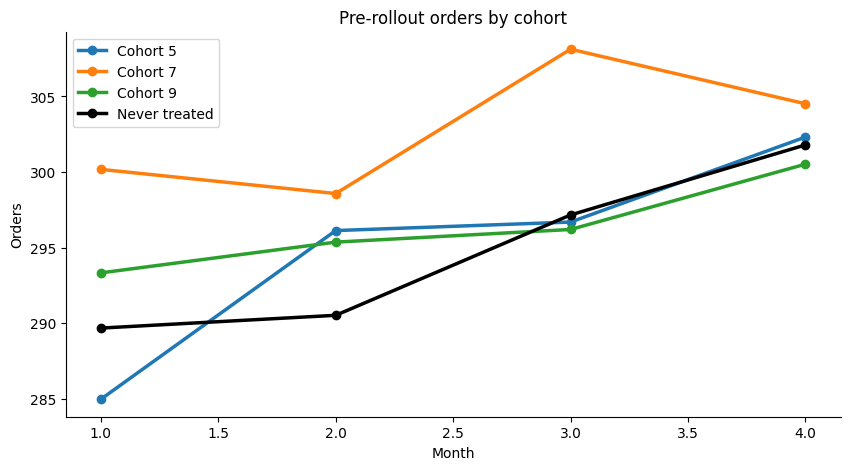

In [18]:
pre_calendar_means = calendar_means[calendar_means["month"] < first_treated_month]

fig, ax = plt.subplots()
for cohort_label, cohort_df in pre_calendar_means.groupby("cohort_label"):
    ax.plot(
        cohort_df["month"],
        cohort_df["orders"],
        color=color_map[cohort_label],
        marker="o",
        linewidth=2.5,
        label=cohort_label,
    )

ax.set_title("Pre-rollout orders by cohort")
ax.set_xlabel("Month")
ax.set_ylabel("Orders")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.legend(frameon=True)
plt.show()

## 3. Why A Naive TWFE Event Study Can Fail

A standard event-study regression adds leads and lags of treatment to a two-way fixed effects model. With staggered adoption and heterogeneous effects, those lead-lag coefficients can be contaminated by comparisons to already-treated units.

That means:
- some post-treatment coefficients can be hard to interpret,
- pre-treatment leads can appear nonzero even when there is no anticipation, and
- the dynamic pattern can differ from the true event-time effect.

We estimate that naive TWFE event study first so the problem is visible.

In [19]:
event_window = [-4, -3, -2, 0, 1, 2, 3]

def event_label(event_time):
    return f"lead_{abs(event_time)}" if event_time < 0 else f"lag_{event_time}"

twfe_event_cols = []
for event_time in event_window:
    column = f"event_{event_label(event_time)}"
    df[column] = ((df["ever_treated"] == 1) & (df["event_time"] == event_time)).astype(int)
    twfe_event_cols.append(column)

twfe_formula = "orders ~ " + " + ".join(twfe_event_cols) + " + C(market_id) + C(month)"
twfe_model = smf.ols(twfe_formula, data=df).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["market_id"]},
)

twfe_results = pd.DataFrame(
    {
        "event_time": event_window,
        "twfe_estimate": [twfe_model.params.get(column, np.nan) for column in twfe_event_cols],
        "twfe_std_error": [twfe_model.bse.get(column, np.nan) for column in twfe_event_cols],
    }
)
twfe_results.round(3)

,event_time,twfe_estimate,twfe_std_error
0,-4,0.293,2.164
1,-3,-0.803,2.436
2,-2,-2.515,2.437
3,0,12.341,2.547
4,1,16.775,2.366
5,2,17.778,2.211
6,3,19.505,2.202


## 4. Sun-Abraham Interaction-Weighted Event Study

The Sun-Abraham fix is to estimate event-time effects separately by cohort and then aggregate them using cohort weights. That avoids contaminating one cohort's event-time effect with already-treated observations from another cohort.

In this simplified instructional version:
- never-treated markets serve as the comparison group,
- we estimate a cohort-specific relative-period effect `CATT(e,l)` for each cohort `e` and event time `l`,
- event time `-1` is the reference period, and
- we aggregate those cohort-specific estimates into an interaction-weighted event-study profile.

In [20]:
treated_cohorts = sorted(markets.loc[markets["ever_treated"] == 1, "cohort"].unique())
cohort_sizes = markets.loc[markets["cohort"] > 0].groupby("cohort").size().to_dict()

def estimate_catt_el(data, cohort, event_time):
    reference_period = cohort - 1
    target_period = cohort + event_time
    if target_period < 1 or target_period > n_months:
        return None

    subset = data.loc[
        ((data["cohort"] == cohort) | (data["cohort"] == 0))
        & (data["month"].isin([reference_period, target_period]))
    ].copy()

    subset["cohort_event_indicator"] = (
        (subset["cohort"] == cohort) & (subset["month"] == target_period)
    ).astype(int)

    model = smf.ols(
        "orders ~ cohort_event_indicator + C(market_id) + C(month)",
        data=subset,
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": subset["market_id"]},
    )

    return {
        "cohort": cohort,
        "event_time": event_time,
        "catt_el": model.params["cohort_event_indicator"],
        "weight": cohort_sizes[cohort],
    }

catt_results = pd.DataFrame(
    result
    for cohort in treated_cohorts
    for event_time in event_window
    for result in [estimate_catt_el(df, cohort, event_time)]
    if result is not None
)

iw_rows = []
for event_time, event_df in catt_results.groupby("event_time"):
    iw_rows.append(
        {
            "event_time": event_time,
            "sun_abraham_iw": np.average(event_df["catt_el"], weights=event_df["weight"]),
        }
    )

iw_results = pd.DataFrame(iw_rows).sort_values("event_time")
iw_results.round(3)

,event_time,sun_abraham_iw
0,-4,1.027
1,-3,-1.189
2,-2,-3.561
3,0,16.119
4,1,19.040
5,2,25.947
6,3,27.251


In [21]:
true_rows = []
for event_time in event_window:
    if event_time < 0:
        true_rows.append({"event_time": event_time, "true_effect": 0.0})
    else:
        true_rows.append(
            {
                "event_time": event_time,
                "true_effect": df.loc[df["event_time"] == event_time, "true_effect"].mean(),
            }
        )

true_results = pd.DataFrame(true_rows)

comparison = (
    twfe_results[["event_time", "twfe_estimate"]]
    .merge(iw_results, on="event_time")
    .merge(true_results, on="event_time")
    .sort_values("event_time")
)
comparison.round(3)

,event_time,twfe_estimate,sun_abraham_iw,true_effect
0,-4,0.293,1.027,0.000
1,-3,-0.803,-1.189,0.000
2,-2,-2.515,-3.561,0.000
3,0,12.341,16.119,15.692
4,1,16.775,19.040,20.923
5,2,17.778,25.947,26.154
6,3,19.505,27.251,30.385


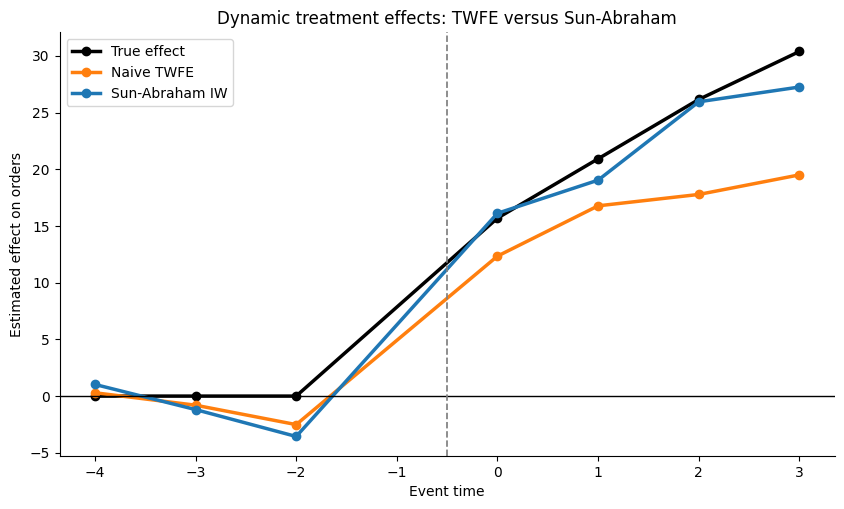

In [22]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(comparison["event_time"], comparison["true_effect"], color="black", linewidth=2.5, marker="o", label="True effect")
ax.plot(comparison["event_time"], comparison["twfe_estimate"], color="tab:orange", linewidth=2.5, marker="o", label="Naive TWFE")
ax.plot(comparison["event_time"], comparison["sun_abraham_iw"], color="tab:blue", linewidth=2.5, marker="o", label="Sun-Abraham IW")
ax.axhline(0, color="black", linewidth=1)
ax.axvline(-0.5, color="gray", linestyle="--", linewidth=1.25)
ax.set_title("Dynamic treatment effects: TWFE versus Sun-Abraham")
ax.set_xlabel("Event time")
ax.set_ylabel("Estimated effect on orders")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.legend(frameon=True)
plt.show()

## 5. Apply DiD And Interpret The Results

The event-study estimates are the DiD results in this notebook.

What to look for:
- Pre-treatment leads should be close to zero if parallel trends is credible.
- Post-treatment lags should trace out the dynamic treatment response.
- If the TWFE line differs materially from the interaction-weighted line, that is exactly the contamination problem Sun and Abraham emphasize.

In [23]:
average_post_twfe = comparison.loc[comparison["event_time"] >= 0, "twfe_estimate"].mean()
average_post_iw = comparison.loc[comparison["event_time"] >= 0, "sun_abraham_iw"].mean()
average_post_true = comparison.loc[comparison["event_time"] >= 0, "true_effect"].mean()

print(f"Average post-treatment naive TWFE estimate: {average_post_twfe:.2f}")
print(f"Average post-treatment Sun-Abraham IW estimate: {average_post_iw:.2f}")
print(f"Average true post-treatment effect: {average_post_true:.2f}")

Average post-treatment naive TWFE estimate: 16.60
Average post-treatment Sun-Abraham IW estimate: 22.09
Average true post-treatment effect: 23.29


## Why We Cluster At The Market Level

The same markets appear repeatedly across months, so the error term can be serially correlated within market over time.

For that reason, both the naive TWFE event-study regression and the Sun-Abraham interaction-weighted regression above use standard errors clustered at `market_id`.

## Takeaways

- This notebook keeps the same staggered marketing rollout as Notebook 02 but allows treatment effects to evolve differently across cohorts.
- The identification assumptions still center on parallel untreated trends, no anticipation, and no spillovers.
- Baseline similarity checks and pre-treatment trajectories are still essential.
- The new issue is estimand contamination: a naive TWFE event-study regression can misstate dynamic effects when treatment effects are heterogeneous.
- The Sun-Abraham interaction-weighted approach estimates cohort-specific event-time effects first and then aggregates them, which is why it better tracks the true dynamic pattern in this setting.

In [24]:
summary = pd.Series({
    "First treated month": first_treated_month,
    "Treated cohorts": len(treated_cohorts),
    "Average post TWFE": round(average_post_twfe, 2),
    "Average post Sun-Abraham": round(average_post_iw, 2),
    "Average true post effect": round(average_post_true, 2),
})
summary

First treated month         5.000
Treated cohorts             3.000
Average post TWFE          16.600
Average post Sun-Abraham   22.090
Average true post effect   23.290
dtype: float64